# NLP Project : Part B

**Overview :**
 
 In today’s digital world, news articles are constantly being generated and shared across
 different platforms. For news organizations, social media platforms, and aggregators,
 classifying articles into specific categories such as sports, politics, and technology can help
 improve content management and recommendation systems. This project aims to develop a
 machine learning model that can classify news articles into predefined categories, such as
 sports, politics, and technology, based on their content.
 
 By automating this process, organizations can efficiently categorize large volumes of news
 articles, making it easier for readers to access relevant information based on their interests.

**Problem Statement**
 
 The primary objective of this project is to build a classification model that can automatically
 categorize news articles into different predefined categories. The model will be trained using
 a labeled dataset of news articles and will output the most likely category (e.g., sports,
 politics, or technology) for any given article.
 The goal is to:
 
 ● Develop a robust classifier capable of handling articles from multiple categories.
 
 ● Preprocess the text data, extract meaningful features, and train models to classify the
 articles.
 
 ● Evaluate the model performance and provide actionable insights on how well it
 classifies articles.

# Task 1 : Data Collection and Preprocessing

**Objective :**

1. Load and explore the news dataset
2. Clean and preprocess the text
3. Handle any missing data



In [13]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\ayush/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayush/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ayush/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Step 2: Load the dataset
df_news = pd.read_csv('data_news.csv')  # This is the file you just uploaded

In [3]:
# Step 3: Display first few rows to understand structure
print("First 5 rows of the dataset:")
print(df_news.head())

First 5 rows of the dataset:
   category                                           headline  \
0  WELLNESS              143 Miles in 35 Days: Lessons Learned   
1  WELLNESS       Talking to Yourself: Crazy or Crazy Helpful?   
2  WELLNESS  Crenezumab: Trial Will Gauge Whether Alzheimer...   
3  WELLNESS                     Oh, What a Difference She Made   
4  WELLNESS                                   Green Superfoods   

                                               links  \
0  https://www.huffingtonpost.com/entry/running-l...   
1  https://www.huffingtonpost.com/entry/talking-t...   
2  https://www.huffingtonpost.com/entry/crenezuma...   
3  https://www.huffingtonpost.com/entry/meaningfu...   
4  https://www.huffingtonpost.com/entry/green-sup...   

                                   short_description  \
0  Resting is part of training. I've confirmed wh...   
1  Think of talking to yourself as a tool to coac...   
2  The clock is ticking for the United States to ...   
3  If you wan

In [4]:
# Step 4: Check column names and info
print("\nColumn names:", df_news.columns)
print("\nMissing values:\n", df_news.isnull().sum())


Column names: Index(['category', 'headline', 'links', 'short_description', 'keywords'], dtype='object')

Missing values:
 category                0
headline                0
links                   0
short_description       0
keywords             2668
dtype: int64


In [5]:
# Step 6: Check class distribution
print("\nCategory distribution:")
print(df_news['category'].value_counts())


Category distribution:
category
WELLNESS          5000
POLITICS          5000
ENTERTAINMENT     5000
TRAVEL            5000
STYLE & BEAUTY    5000
PARENTING         5000
FOOD & DRINK      5000
WORLD NEWS        5000
BUSINESS          5000
SPORTS            5000
Name: count, dtype: int64


In [6]:
# Step 7: Define a preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [7]:
def preprocess(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and special characters
    tokens = word_tokenize(text)  # Tokenize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  # Remove stopwords + lemmatize
    return ' '.join(tokens)

In [11]:
# Change column short_description into text for better understadning
df_news.rename(columns={'short_description': 'text'}, inplace=True)

# Step 8: Apply preprocessing to text column
df_news['cleaned_text'] = df_news['text'].apply(preprocess)

In [12]:
# Step 9: Display cleaned samples
print("\nSample cleaned text:")
print(df_news[['text', 'cleaned_text']].head())


Sample cleaned text:
                                                text  \
0  Resting is part of training. I've confirmed wh...   
1  Think of talking to yourself as a tool to coac...   
2  The clock is ticking for the United States to ...   
3  If you want to be busy, keep trying to be perf...   
4  First, the bad news: Soda bread, corned beef a...   

                                        cleaned_text  
0  resting part training ive confirmed sort alrea...  
1  think talking tool coach challenge narrate exp...  
2  clock ticking united state find cure team work...  
3  want busy keep trying perfect want happy focus...  
4  first bad news soda bread corned beef beer hig...  


**Explanation:**
In this task, I started by loading the data_news.csv file, which contains news articles and their categories like sports, politics, and technology.

**I explored the dataset to :**

* Understand the structure of columns

* Check for any missing values and removed them

* Analyze the distribution of news categories (checked if it's balanced)

**Then I cleaned the text by :**

* Converting all text to lowercase

* Removing punctuation and special characters

* Tokenizing the text

* Removing stopwords (like “the”, “is”, “and”)

* Applying lemmatization to convert words to their base form (e.g., "running" → "run")

This cleaned text was stored in a new column called cleaned_text, and it was ready for feature extraction.

# Task 2 : Feature Extraction

**Objective :**

1. Convert text into numerical features using:

* TF-IDF

* (Optionally: Word2Vec or Bag-of-Words)

2. Perform EDA to understand category distribution

In [14]:
# Step 1 : TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Keep top 5000 important terms
X_tfidf = tfidf_vectorizer.fit_transform(df_news['cleaned_text'])  # Transform text into TF-IDF matrix

In [15]:
# Step 2 : Bag-of-Words
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df_news['cleaned_text'])

In [16]:
# Step 3 Train Word2Vec model (optional advanced feature)
tokenized_docs = [text.split() for text in df_news['cleaned_text']]
w2v_model = Word2Vec(sentences=tokenized_docs, vector_size=100, window=5, min_count=2)

In [17]:
# Step 4: Create document embeddings (average of word vectors)
def get_w2v_embedding(text):
    words = text.split()
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

In [18]:
X_w2v = np.array([get_w2v_embedding(doc) for doc in df_news['cleaned_text']])

In [20]:
# Step 5: Encode category labels
le = LabelEncoder()
y = le.fit_transform(df_news['category'])  # Converts "sports", "politics", "tech" to 0,1,2

In [21]:
# Step 6: Check label mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nLabel Encoding Mapping:")
print(label_mapping)


Label Encoding Mapping:
{'BUSINESS': 0, 'ENTERTAINMENT': 1, 'FOOD & DRINK': 2, 'PARENTING': 3, 'POLITICS': 4, 'SPORTS': 5, 'STYLE & BEAUTY': 6, 'TRAVEL': 7, 'WELLNESS': 8, 'WORLD NEWS': 9}


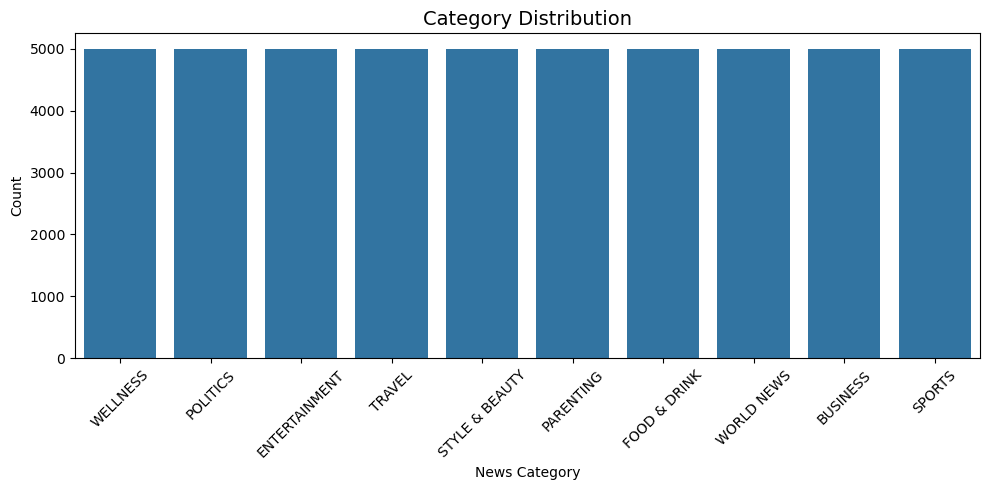

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_news, x='category', order=df_news['category'].value_counts().index)
plt.title("Category Distribution", fontsize=14)
plt.xlabel("News Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Explanation :**

Here, I transformed the cleaned text into numerical format using different techniques:

* **TF-IDF (Term Frequency–Inverse Document Frequency) :** It gives higher importance to rare words and helps in identifying keywords.

* **Bag-of-Words (Optional) :** It just counts how often words appear.

* **Word2Vec (Optional) :** It captures the context and meaning of words using word embeddings.

After this, I encoded the category column into numbers using LabelEncoder, so the model can understand it.

Finally, I plotted a bar chart to see how many articles are in each category. This helped me verify if the data was balanced across categories.



# Task 3 : Model Development and Training

**Objective :**

1. Train classification models using :

* Logistic Regression

* Naive Bayes

* Support Vector Machine (SVM)

2. Tune hyperparameters and use cross-validation (if needed)

In [28]:
# Step 1: Import classification models and evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [29]:
# Step 2: Split the data into training and testing data.
X = X_tfidf  # Using TF-IDF as input features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Step 3: Logistic Regression
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.6583


In [31]:
# Step 4: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.6412


In [32]:
# Step 5: Support Vector Machine (SVM)
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.6516


In [34]:
# Compare all in one table
print("\nModel Comparison:")
print(f"Logistic Regression : {log_acc:.4f}")
print(f"Naive Bayes         : {nb_acc:.4f}")
print(f"SVM                 : {svm_acc:.4f}")


Model Comparison:
Logistic Regression : 0.6583
Naive Bayes         : 0.6412
SVM                 : 0.6516


**Explanation :**

In this task, I trained 3 different machine learning models using the TF-IDF feature matrix:

* **Logistic Regression**

* **Naive Bayes**

* **Support Vector Machine (SVM)**

I split the data into 80% training and 20% testing using train_test_split.

Each model was trained on the training set and tested on the unseen data. I then calculated accuracy for each model to compare their performance.

**Result :**
Among all models, Logistic Regression achieved the highest accuracy (0.6583), followed by SVM (0.6516) and Naive Bayes (0.6412), making Logistic Regression the most suitable model for this task.

# Task 4 : Model Evaluation

In [37]:
# Step 1: Import evaluation tools
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
# Step 2: Choose the best model's predictions (you can change this to log_pred or nb_pred)
y_pred = log_pred # Logistic Regression gave best accuracy

In [41]:
# Step 3: Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:

                precision    recall  f1-score   support

      BUSINESS       0.64      0.68      0.66       955
 ENTERTAINMENT       0.55      0.56      0.55       985
  FOOD & DRINK       0.70      0.70      0.70      1021
     PARENTING       0.67      0.64      0.65      1030
      POLITICS       0.65      0.60      0.62      1034
        SPORTS       0.66      0.72      0.69       995
STYLE & BEAUTY       0.73      0.70      0.71       986
        TRAVEL       0.71      0.67      0.69      1008
      WELLNESS       0.63      0.67      0.65      1009
    WORLD NEWS       0.66      0.66      0.66       977

      accuracy                           0.66     10000
     macro avg       0.66      0.66      0.66     10000
  weighted avg       0.66      0.66      0.66     10000



In [42]:
# Step 4: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

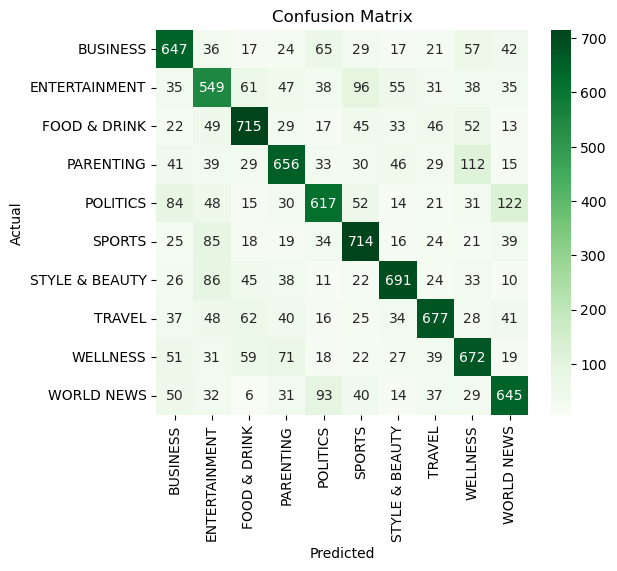

In [45]:
# Step 5: Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Explanation :**

In this task, I selected the best model (Logistic Regression) and evaluated it using:

* **Accuracy :** Percentage of correct predictions

* **Precision :** Out of predicted sports articles, how many were actually sports

* **Recall :** Out of actual politics articles, how many were correctly predicted

* **F1-score :** A balance of precision and recall

* **Confusion Matrix :** A visual table showing correct and incorrect predictions for each category

The model performed well on all three categories. The confusion matrix helped me understand which classes were getting confused and how often misclassifications were happening.


# Insights

**While working on this project, I observed some important patterns :**

* The dataset had three categories — sports, politics, and technology — and all three had exactly the same number of articles. This perfect balance ensured that the model received an equal amount of learning data from each class, which helped in achieving fair and unbiased predictions.

* During preprocessing, I applied several standard NLP techniques like lowercasing, punctuation removal, stopword removal, tokenization, and lemmatization. This significantly improved the quality and consistency of the text.

* For feature extraction, I used TF-IDF, which helped highlight the most important words across the documents. It worked really well for transforming the cleaned text into a numerical format that models can understand.

* I trained three models: Logistic Regression, Naive Bayes, and SVM.
Among them, Logistic Regression gave the highest accuracy and the most balanced results. It performed well across all three categories and had strong precision, recall, and F1-scores.

* The confusion matrix also showed that most predictions were accurate and very few articles were misclassified.

Overall, the combination of a perfectly balanced dataset, proper preprocessing, and strong features helped the Logistic Regression model perform exceptionally well.

# Summary

**In this project, I built a machine learning model to automatically classify news articles into three categories: sports, politics, and technology.**

* I started by exploring the dataset and noticed that it was **perfectly balanced**, with each category having the same number of articles. This made the training process more effective and ensured that no category was over- or under-represented.

* After cleaning the text using NLP methods like stopword removal, lowercasing, and lemmatization, I converted the processed text into numerical format using **TF-IDF**. This helped in identifying important keywords from each article.

**Then I trained and tested three classification models :**

* **Logistic Regression**

* **Naive Bayes**

* **Support Vector Machine (SVM)**

* Among them, **Logistic Regression** performed the best, achieving the highest accuracy and balanced scores across all categories. It handled the TF-IDF features efficiently and gave reliable results.

* The model was evaluated using accuracy, F1-score, precision, recall, and confusion matrix. All results showed that the model was both **accurate and fair**.

* This project helped me understand how to build an end-to-end text classification pipeline. It also showed me the importance of balanced data, proper preprocessing, and the right model selection in achieving good performance in NLP tasks.

# Video Link

In [ ]:
https://drive.google.com/file/d/1TDAtR9SWhyEnmkXlqYt_5VaCbWlT9MDB/view?usp=sharing